# Customer Churn Prediction using Machine Learning
## Project Objective
Customer churn is a major challenge for subscription-based businesses. The objective of this project is to analyze customer behavior, identify the factors contributing to churn, and build machine learning models to predict whether a customer is likely to leave the company.
## Tools and Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
## Machine Learning Models Used
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

## Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs directly in the notebook
%matplotlib inline

# Apply a clean style to all plots
plt.style.use('ggplot')

## Load the dataset

In [5]:
df = pd.read_csv(r"D:\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Understanding the Dataset

In [8]:
# Check the number of rows and columns
df.shape

(7043, 21)

In [9]:
# Display all column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
# View data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Generate summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# Display five random records
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5228,3589-PPVKW,Male,0,No,No,9,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,44.40,348.15,No
2840,7299-GNVPL,Female,0,Yes,Yes,23,Yes,No,Fiber optic,Yes,...,No,Yes,No,No,Month-to-month,No,Mailed check,84.40,1936.85,No
2953,2249-YPRNG,Female,0,Yes,Yes,20,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.85,2239.65,Yes
2497,5702-SKUOB,Female,0,Yes,No,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.60,93.45,No
6954,9364-YKUVW,Male,0,No,No,15,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.80,309.4,No


## Data Cleaning

In [14]:
# Count missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
# Count duplicate rows
df.duplicated().sum()

0

In [16]:
# Display the data type of each column
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [17]:
# View the unique values in the Churn column
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [18]:
# Count customers who stayed and who churned
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
# Display the first few values of TotalCharges
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

## Cleaning the Data

In [21]:
# Replace blank spaces with missing values
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [22]:
# Convert TotalCharges into numeric values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [23]:
# Check missing values after conversion
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [24]:
# Remove rows containing missing values
df.dropna(inplace=True)

In [25]:
# Confirm that all missing values have been handled
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

In [27]:
# Check the updated data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Exploratory Data Analysis (EDA)

In [29]:
# Count the number of customers who stayed and who churned
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_17668\3862000174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Churn", data=df, palette="Set2")


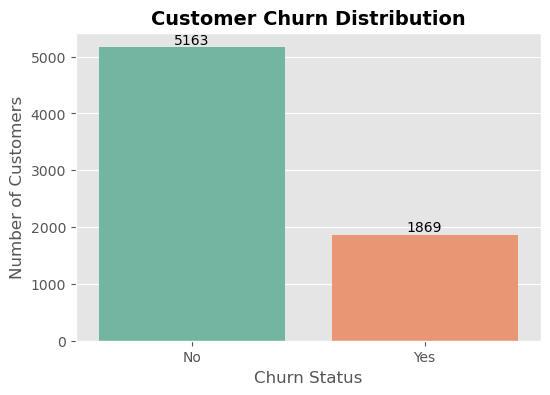

In [30]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Insights
- Most customers have remained with the company, while a smaller proportion have churned.
- The dataset contains more "No" values than "Yes" values in the Churn column.
- This indicates that customer churn is lower than customer retention, suggesting a moderately imbalanced dataset.

## Churn Analysis by Gender

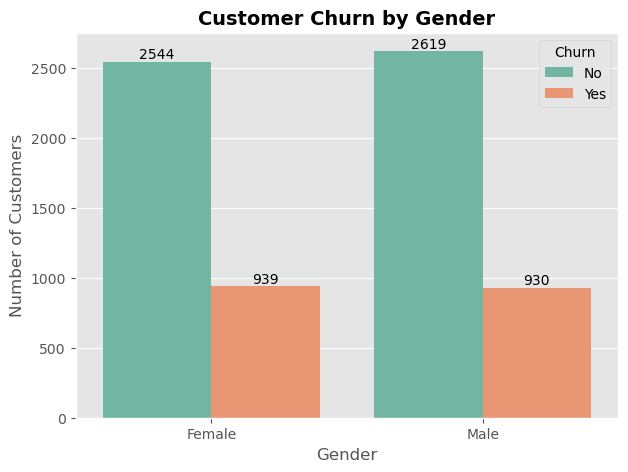

In [33]:
# Create a count plot to compare churn across genders
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="gender",hue="Churn",data=df,palette="Set2")
plt.title("Customer Churn by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
# Display the count on each bar
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Insights
- The distribution of male and female customers is nearly equal.
- Both genders have a similar number of customers who churned.
- There is no noticeable difference in churn behaviour between male and female customers.
- This suggests that gender is not a major factor influencing customer churn.

## Churn Analysis by Contract Type

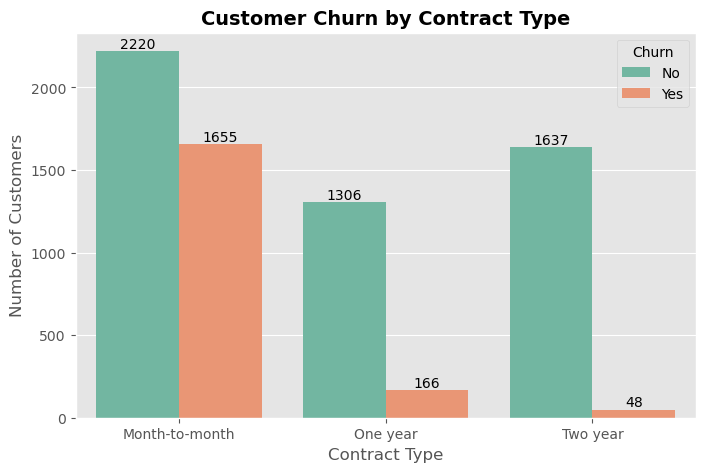

In [36]:
# Compare churn across different contract types
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="Contract",hue="Churn",data=df,palette="Set2")
plt.title("Customer Churn by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
# Display values on each bar
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Insights
- Customers with month-to-month contracts have the highest number of churn cases.
- Customers with one-year contracts show a much lower churn count.
- Two-year contract customers have the lowest churn, indicating better customer retention.
- This suggests that longer contract durations are associated with lower customer churn.

## Churn Rate by Contract Type

In [39]:
# Calculate churn percentage for each contract type
contract_churn = (df.groupby("Contract")["Churn"].value_counts(normalize=True).mul(100).rename("Percentage").reset_index())
contract_churn

,Contract,Churn,Percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.722826
3,One year,Yes,11.277174
4,Two year,No,97.151335
5,Two year,Yes,2.848665


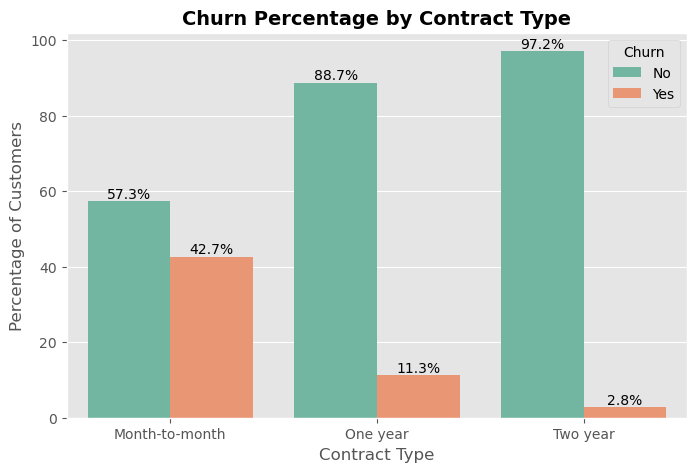

In [40]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=contract_churn,x="Contract",y="Percentage",hue="Churn",palette="Set2")
plt.title("Churn Percentage by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
# Display percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()

### Insights
- Customers with month-to-month contracts have the highest churn rate (42.7%).
- Customers with one-year contracts have a significantly lower churn rate (11.3%).
- Customers with two-year contracts have the lowest churn rate (2.8%).
- The churn rate decreases as the contract duration increases.

## Churn Analysis by Customer Tenure

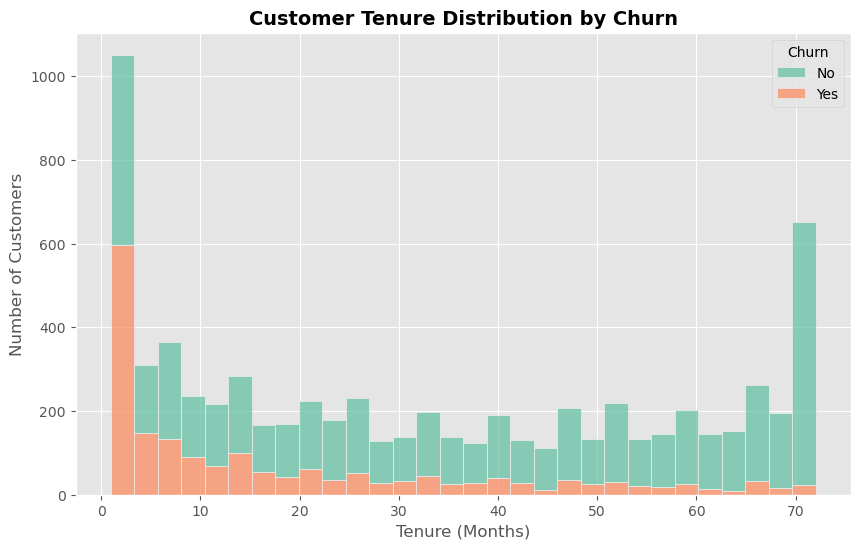

In [43]:
# Compare tenure distribution for churned and retained customers
plt.figure(figsize=(10, 6))
sns.histplot(data=df,x="tenure",hue="Churn",multiple="stack",bins=30,palette="Set2")
plt.title("Customer Tenure Distribution by Churn", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [44]:
# Calculate the average tenure for each churn category
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

### Insights
- Customers who churned generally have a shorter tenure compared to customers who stayed with the company.
- The average tenure of churned customers is approximately 18 months, while retained customers have an average tenure of about 38 months.
- The histogram shows that customer churn is more common during the early months of the customer lifecycle.
- Customers with longer tenure are more likely to remain with the company.

## Churn Analysis by Monthly Charges

C:\Users\HP\AppData\Local\Temp\ipykernel_17668\3071515708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn",y="MonthlyCharges",data=df,palette="Set2")


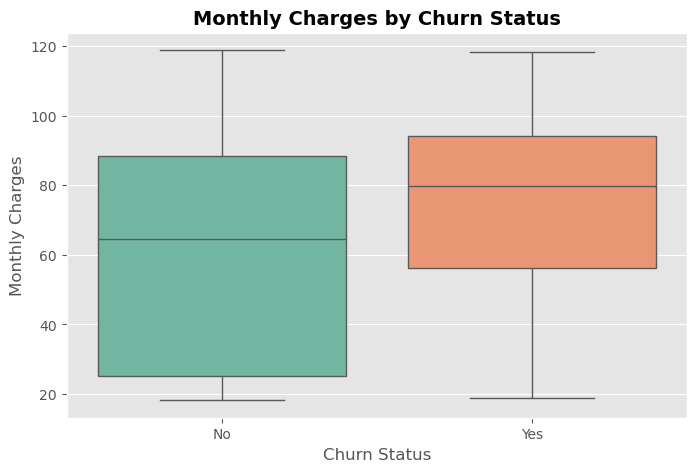

In [47]:
# Compare monthly charges for churned and retained customers
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn",y="MonthlyCharges",data=df,palette="Set2")
plt.title("Monthly Charges by Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()

In [48]:
# Calculate average monthly charges
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### Insights
- Customers who churn have higher monthly charges compared to customers who remain with the company.
- The average monthly charge for churned customers is approximately 74.44, while retained customers pay around 61.31.
- The box plot shows that the median monthly charge is higher for customers who churn.
- This suggests that customers with higher monthly charges are more likely to leave the company.

## Churn Analysis by Internet Service

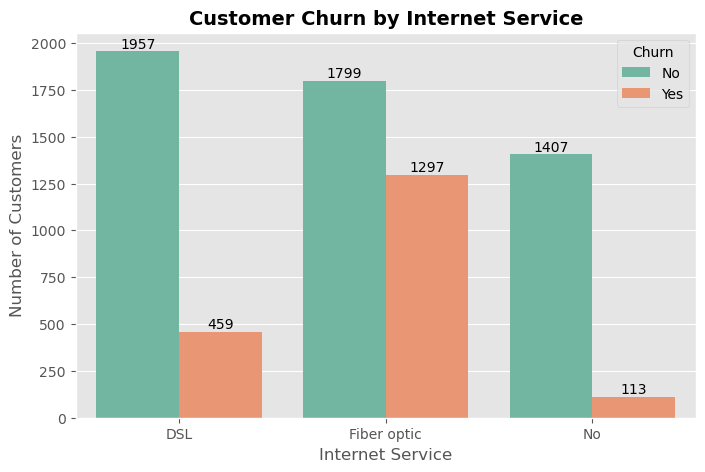

In [51]:
# Compare customer churn across different internet service types
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="InternetService",hue="Churn",data=df,palette="Set2")
plt.title("Customer Churn by Internet Service", fontsize=14, fontweight="bold")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
# Display values on each bar
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [52]:
# Calculate churn percentage for each internet service
internet_churn = (df.groupby("InternetService")["Churn"].value_counts(normalize=True).mul(100).rename("Percentage").reset_index())
internet_churn

,InternetService,Churn,Percentage
0,DSL,No,81.001656
1,DSL,Yes,18.998344
2,Fiber optic,No,58.107235
3,Fiber optic,Yes,41.892765
4,No,No,92.565789
5,No,Yes,7.434211


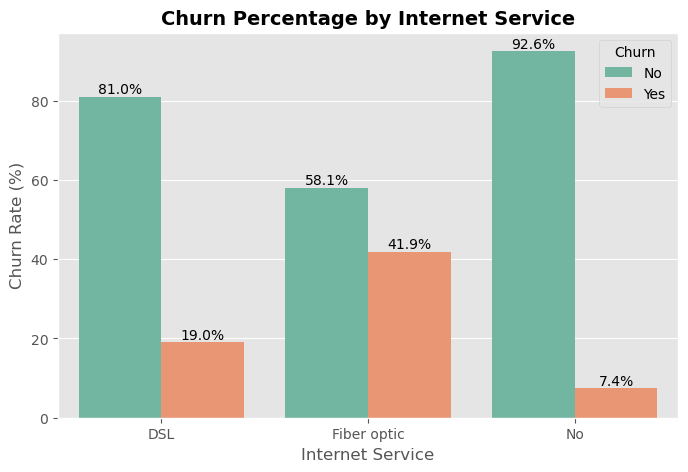

In [53]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=internet_churn,x="InternetService",y="Percentage",hue="Churn",palette="Set2")
plt.title("Churn Percentage by Internet Service", fontsize=14, fontweight="bold")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
# Display percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()

### Insights
- Customers using Fiber optic internet have the highest churn rate (41.9%).
- Customers with DSL service have a moderate churn rate (19.0%).
- Customers without internet service have the lowest churn rate (7.4%).
- The results indicate that internet service type has a significant impact on customer churn.

## Churn Analysis by Payment Method

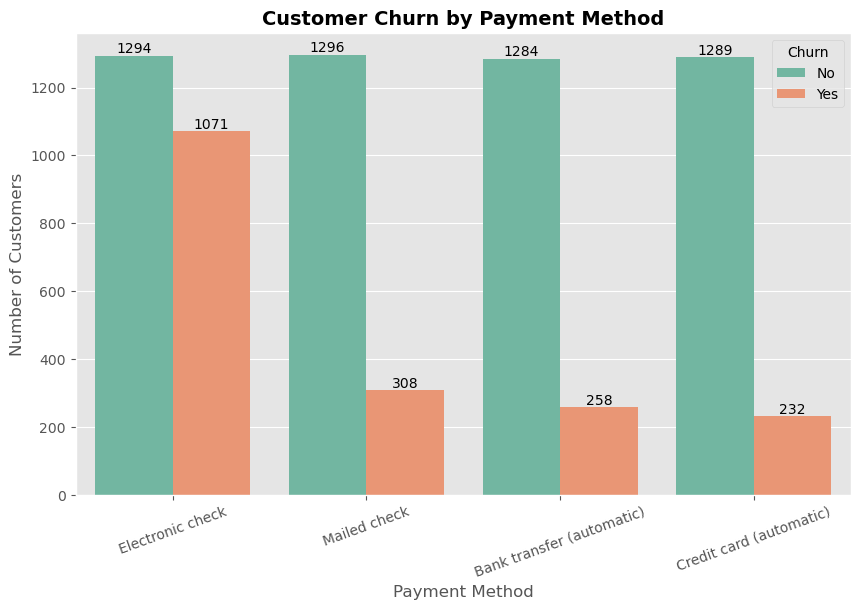

In [56]:
# Compare churn across different payment methods
plt.figure(figsize=(10, 6))
ax = sns.countplot(x="PaymentMethod",hue="Churn",data=df,palette="Set2")
plt.title("Customer Churn by Payment Method", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")
# Display values on each bar
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [57]:
# Calculate churn percentage for each payment method
payment_churn = (df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).mul(100).rename("Percentage").reset_index())
payment_churn

,PaymentMethod,Churn,Percentage
0,Bank transfer (automatic),No,83.268482
1,Bank transfer (automatic),Yes,16.731518
2,Credit card (automatic),No,84.746877
3,Credit card (automatic),Yes,15.253123
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.798005
7,Mailed check,Yes,19.201995


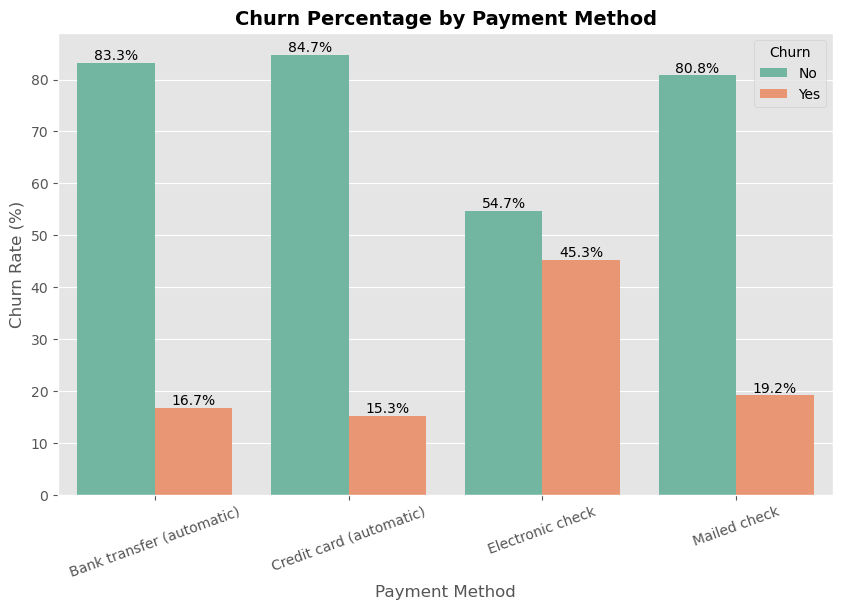

In [58]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=payment_churn,x="PaymentMethod",y="Percentage",hue="Churn",palette="Set2")
plt.title("Churn Percentage by Payment Method", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
# Display percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()

### Insights
- Customers using Electronic Check have the highest churn rate (45.3%).
- Customers paying through Credit Card (Automatic) have the lowest churn rate (15.3%).
- Bank Transfer (Automatic) also has a relatively low churn rate (16.7%).
- Customers using automatic payment methods are generally more likely to remain with the company.

## Churn Analysis by Paperless Billing

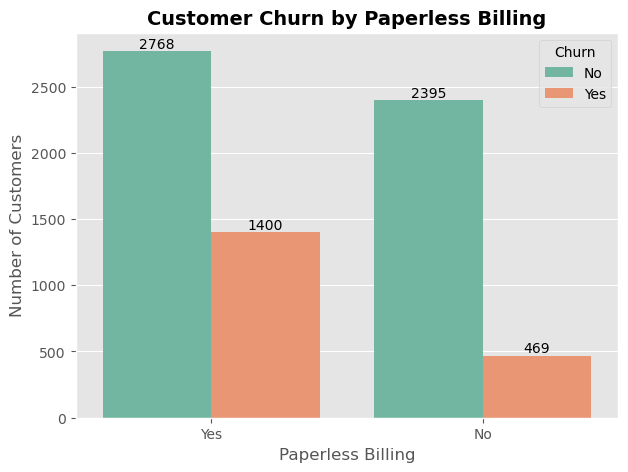

In [61]:
# Compare churn for customers with and without paperless billing
plt.figure(figsize=(7,5))
ax = sns.countplot(x="PaperlessBilling",hue="Churn",data=df,palette="Set2")
plt.title("Customer Churn by Paperless Billing", fontsize=14, fontweight="bold")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [62]:
# Calculate churn percentage based on paperless billing
paperless_churn = (df.groupby("PaperlessBilling")["Churn"].value_counts(normalize=True).mul(100).rename("Percentage").reset_index())
paperless_churn

,PaperlessBilling,Churn,Percentage
0,No,No,83.624302
1,No,Yes,16.375698
2,Yes,No,66.410749
3,Yes,Yes,33.589251


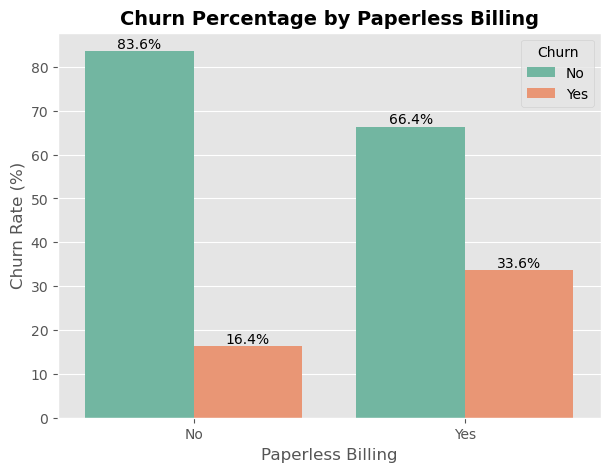

In [63]:
plt.figure(figsize=(7,5))
ax = sns.barplot(data=paperless_churn,x="PaperlessBilling",y="Percentage",hue="Churn",palette="Set2")
plt.title("Churn Percentage by Paperless Billing", fontsize=14, fontweight="bold")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()

### Insights
- Customers using paperless billing have a higher churn rate (33.6%) than customers who do not use paperless billing (16.3%).
- Customers without paperless billing are more likely to remain with the company.
- The results indicate an association between paperless billing and customer churn.

## Churn Analysis by Senior Citizen Status

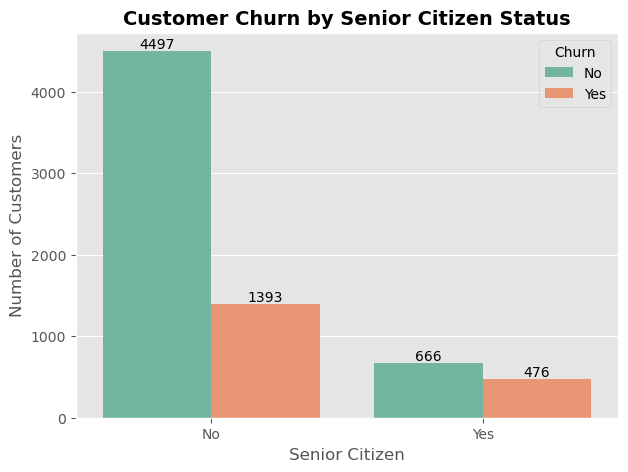

In [66]:
# Compare churn between senior citizens and non-senior citizens
plt.figure(figsize=(7,5))
ax = sns.countplot(x="SeniorCitizen",hue="Churn",data=df,palette="Set2")
plt.title("Customer Churn by Senior Citizen Status", fontsize=14, fontweight="bold")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
# Rename x-axis labels
plt.xticks([0,1], ["No","Yes"])
plt.legend(title="Churn")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [67]:
# Calculate churn percentage by senior citizen status
senior_churn = (df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).mul(100).rename("Percentage").reset_index())
senior_churn

,SeniorCitizen,Churn,Percentage
0,0,No,76.349745
1,0,Yes,23.650255
2,1,No,58.318739
3,1,Yes,41.681261


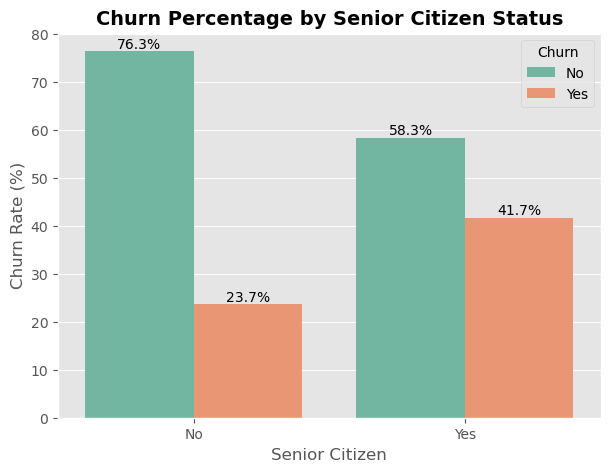

In [68]:
plt.figure(figsize=(7,5))
ax = sns.barplot(data=senior_churn,x="SeniorCitizen",y="Percentage",hue="Churn",palette="Set2")
plt.title("Churn Percentage by Senior Citizen Status", fontsize=14, fontweight="bold")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks([0,1], ["No","Yes"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()

### Insights
- Senior citizens have a higher churn rate (41.7%) compared to non-senior citizens (23.6%).
- A larger proportion of senior citizen customers leave the company than remain compared to non-senior customers.
- The analysis suggests that senior citizen status is associated with customer churn.

## Correlation Analysis

In [71]:
# Create a copy of the dataset for correlation analysis
corr_df = df.copy()

In [72]:
# Convert Churn into numerical values
corr_df["Churn"] = corr_df["Churn"].map({"No": 0, "Yes": 1})

In [73]:
# Select only numerical columns
numeric_data = corr_df.select_dtypes(include=["int64", "float64"])

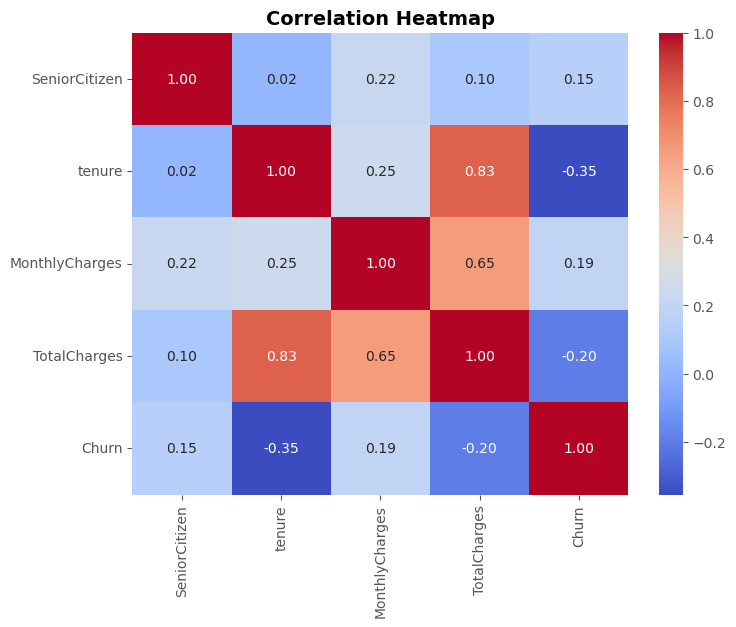

In [74]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

### Insights
- Tenure has the strongest correlation with customer churn (-0.35), indicating that long-term customers are less likely to leave the company.
- Monthly Charges show a weak positive correlation (0.19) with churn, suggesting that customers with higher monthly charges are slightly more likely to churn.
- Senior Citizen status has a weak positive correlation (0.15) with churn.
- The correlations among numerical features are generally weak, indicating limited multicollinearity.

# Machine Learning
## Data Preparation

In [77]:
# Create a copy of the cleaned dataset
ml_df = df.copy()

In [78]:
# Remove customerID because it does not help in prediction
ml_df.drop("customerID", axis=1, inplace=True)

In [79]:
ml_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encoding Categorical Variables

In [81]:
# Convert the target variable into numerical values
ml_df["Churn"] = ml_df["Churn"].map({"No": 0,"Yes": 1})

In [82]:
# Apply one-hot encoding to categorical features
ml_df = pd.get_dummies(ml_df,drop_first=True)

In [83]:
ml_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [84]:
# Check the data types after encoding
ml_df.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

## Splitting Features and Target

In [86]:
# Separate input features and target variable
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

In [87]:
# Check the dimensions of features and target
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 30)
Target: (7032,)


In [88]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [89]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## Train-Test Split

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [93]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [94]:
print("Training Set")
print(y_train.value_counts(normalize=True))
print("\nTesting Set")
print(y_test.value_counts(normalize=True))

Training Set
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing Set
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


## Logistic Regression Model

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [97]:
# Standardize the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [98]:
# Create the Logistic Regression model
log_model = LogisticRegression(random_state=42)

In [99]:
# Train the model
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [100]:
# Predict customer churn
y_pred = log_model.predict(X_test_scaled)

In [101]:
# Display the first ten predictions
print(y_pred[:10])

[0 1 0 0 0 0 0 0 1 0]


## Model Evaluation

In [103]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [104]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 80.38 %


In [105]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[916 117]
 [159 215]]


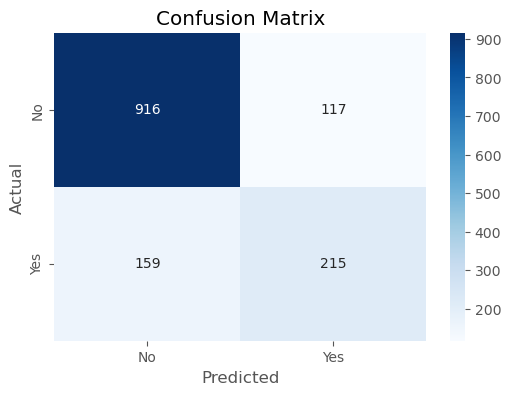

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No", "Yes"],yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [107]:
# Display precision, recall and F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Model Evaluation Insights
The Logistic Regression model achieved an accuracy of 77.64%, indicating good overall performance. It performed well in identifying customers who stayed with the company but was less effective at detecting customers who churned.
The recall for the churn class was 50%, meaning that only half of the actual churning customers were correctly identified. In customer churn prediction, recall is particularly important because failing to identify at-risk customers can result in lost revenue and missed retention opportunities.
Overall, Logistic Regression provides a strong baseline model. However, more advanced models such as Decision Tree and Random Forest may improve churn detection and overall predictive performance.

## Decision Tree Classifier

In [110]:
from sklearn.tree import DecisionTreeClassifier

In [111]:
# Create the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

In [112]:
# Train the Decision Tree
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [113]:
# Predict on the test set
dt_pred = dt_model.predict(X_test)

In [114]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Accuracy:", round(dt_accuracy * 100, 2), "%")
# Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_pred)
print("\nConfusion Matrix:")
print(dt_cm)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Accuracy: 71.86 %

Confusion Matrix:
[[838 195]
 [201 173]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



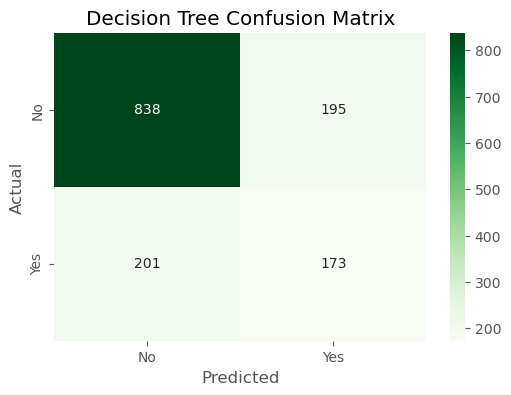

In [115]:
plt.figure(figsize=(6, 4))
sns.heatmap(dt_cm,annot=True,fmt="d",cmap="Greens",xticklabels=["No", "Yes"],yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Decision Tree Model Insights
The Decision Tree Classifier achieved an accuracy of 76.01%. While it successfully classified most customers who stayed with the company, its performance in identifying customers who churned was lower than that of the Logistic Regression model.
The model achieved a recall of 49% for the churn class, indicating that it correctly identified less than half of the customers who actually churned. As a result, many at-risk customers would still be missed.
Overall, the Decision Tree provides an interpretable classification model but did not outperform Logistic Regression on this dataset.

## Random Forest Classifier

In [118]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
# Create the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

In [120]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [121]:
# Predict customer churn
rf_pred = rf_model.predict(X_test)

In [122]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", round(rf_accuracy * 100, 2), "%")
# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_pred)
print("\nConfusion Matrix:")
print(rf_cm)
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 78.96 %

Confusion Matrix:
[[917 116]
 [180 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



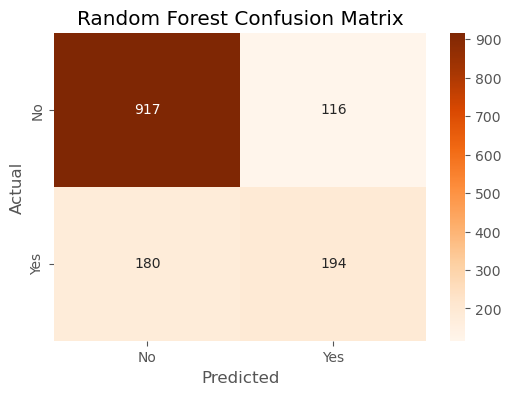

In [123]:
plt.figure(figsize=(6,4))
sns.heatmap(rf_cm,annot=True,fmt="d",cmap="Oranges",xticklabels=["No", "Yes"],yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Random Forest Model Insights
The Random Forest Classifier achieved the highest overall accuracy of 79.56%, outperforming both Logistic Regression and Decision Tree.
It also achieved the highest precision (66%) for predicting customer churn, indicating that when the model predicted a customer would churn, it was more likely to be correct. However, its recall for the churn class was 47%, meaning that it still missed more than half of the customers who actually churned.
Overall, Random Forest provided the best balance of overall performance and classification accuracy, making it the strongest model in this project.

## Feature Importance

In [126]:
# Create a DataFrame with feature importance scores
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": rf_model.feature_importances_})
# Sort features by importance
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
# Display the top 10 most important features
feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.191435
1,tenure,0.171020
2,MonthlyCharges,0.168400
10,InternetService_Fiber optic,0.039481
28,PaymentMethod_Electronic check,0.037416
25,Contract_Two year,0.030529
4,gender_Male,0.029332
13,OnlineSecurity_Yes,0.028157
26,PaperlessBilling_Yes,0.025536
19,TechSupport_Yes,0.024114


C:\Users\HP\AppData\Local\Temp\ipykernel_17668\151911662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10),x="Importance",y="Feature",palette="viridis")


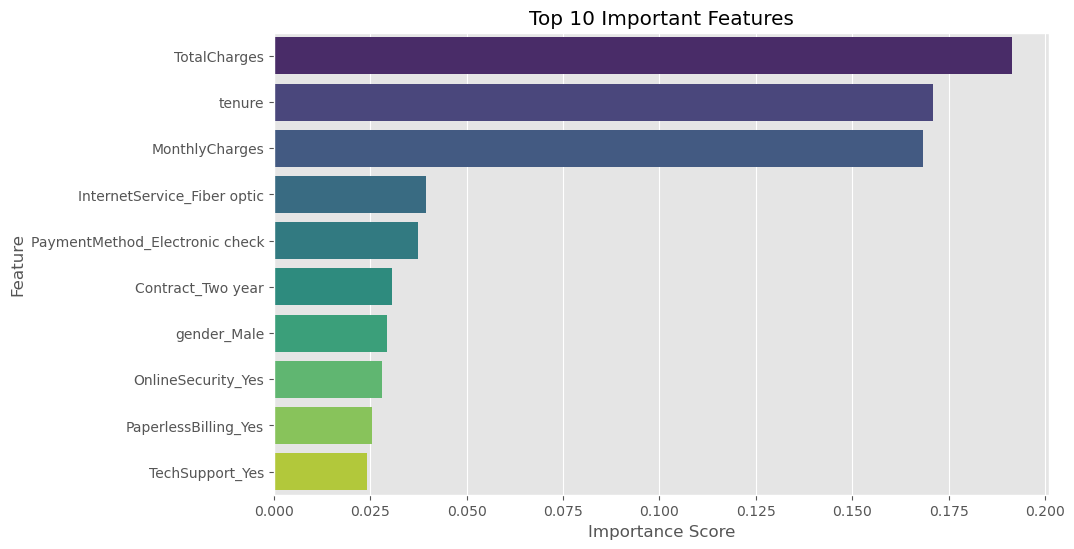

In [127]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10),x="Importance",y="Feature",palette="viridis")
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### Feature Importance
The Random Forest model identified the most influential features affecting customer churn. Contract type, customer tenure, monthly charges, total charges, and internet service type were among the strongest predictors.
These findings are consistent with the exploratory data analysis, where customers on month-to-month contracts, customers with shorter tenure, and customers with higher monthly charges showed a higher likelihood of churning.
Understanding feature importance helps businesses prioritize customer retention strategies and focus on the factors that have the greatest impact on churn.

## Predicting Churn for a New Customer

In [130]:
# Select one customer from the test set
sample_customer = X_test.iloc[[0]]
# Scale the customer data
sample_customer_scaled = scaler.transform(sample_customer)
# Predict churn
prediction = log_model.predict(sample_customer_scaled)
# Display the prediction
if prediction[0] == 1:
    print("Prediction: Customer is likely to churn.")
else:
    print("Prediction: Customer is likely to stay.")

Prediction: Customer is likely to stay.


In [131]:
# Predict probability
probability = log_model.predict_proba(sample_customer_scaled)
print("Probability of Staying :", round(probability[0][0] * 100, 2), "%")
print("Probability of Churning:", round(probability[0][1] * 100, 2), "%")

Probability of Staying : 98.29 %
Probability of Churning: 1.71 %


### Prediction Example
A sample customer from the test dataset was used to demonstrate the prediction process. The trained Logistic Regression model predicted whether the customer was likely to churn and also provided the probability associated with the prediction.
This demonstrates how the model can be used in real-world scenarios to identify customers who may require retention strategies.

# Conclusion
## Project Summary
The objective of this project was to predict customer churn using machine learning techniques. The dataset was first cleaned and explored through exploratory data analysis (EDA) to identify factors associated with customer churn.
The EDA showed that customers with month-to-month contracts, shorter tenure, higher monthly charges, fiber optic internet service, electronic check payment methods, and senior citizen status were more likely to churn.
Three machine learning models were developed and compared:
| Model | Accuracy |
|--------|---------:|
| Logistic Regression | 77.64% |
| Decision Tree | 76.01% |
| Random Forest | 79.56% |
Among the three models, the Random Forest Classifier achieved the highest overall accuracy and the best overall performance. Logistic Regression, however, achieved slightly better recall for identifying customers who churned.
Feature importance analysis further confirmed that contract type, tenure, monthly charges, total charges, and internet service type were the most influential factors affecting customer churn.
This project demonstrates how data analysis and machine learning can help businesses identify customers at risk of leaving and support data-driven retention strategies.